# ⚖️ Notebook 05 — Gestion du Déséquilibre des Classes
## Section 4.3 du Cahier des Charges

**Objectif :** Comparer l'impact des techniques de resampling sur un modèle fixe.

**Techniques testées (même modèle XGBoost, même données) :**
- Aucun resampling (baseline brut)
- SMOTE — Synthetic Minority Over-sampling Technique
- ADASYN — Adaptive Synthetic Sampling
- RandomUnderSampler — Sous-échantillonnage de la classe majoritaire


In [1]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [2]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, average_precision_score,
                              classification_report, confusion_matrix)
from imblearn.over_sampling  import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb

print("✅ Bibliothèques chargées")


✅ Bibliothèques chargées


## 1. Chargement des Données (Sans Resampling)

In [4]:
df = None
X_train_raw, y_train_raw, X_test, y_test = None, None, None, None

try:
    df = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X = df.drop('Class', axis=1).values
    y = df['Class'].values

    X_train, X_test_raw, y_train_raw, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test     = scaler.transform(X_test_raw)

    print(f"✅ Dataset chargé : {df.shape[0]:,} transactions")
    print(f"   Train brut : {X_train_sc.shape} | Fraudes : {y_train_raw.sum()} ({y_train_raw.mean()*100:.3f}%)")
    print(f"   Test       : {X_test.shape}     | Fraudes : {y_test.sum()} ({y_test.mean()*100:.3f}%)")
except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


✅ Dataset chargé : 284,807 transactions
   Train brut : (227845, 30) | Fraudes : 394 (0.173%)
   Test       : (56962, 30)     | Fraudes : 98 (0.172%)


## 2. Préparation des Datasets Resampleés

In [5]:
if df is not None:
    # ── Aucun resampling ──────────────────────────────────────────────────
    datasets = {
        'Aucun (brut)': (X_train_sc, y_train_raw),
    }

    # ── SMOTE ─────────────────────────────────────────────────────────────
    print("⏳ Application SMOTE...")
    X_sm, y_sm = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train_sc, y_train_raw)
    datasets['SMOTE'] = (X_sm, y_sm)
    print(f"   SMOTE    → {X_sm.shape[0]:,} samples | Balance: {y_sm.mean()*100:.1f}%")

    # ── ADASYN ────────────────────────────────────────────────────────────
    print("⏳ Application ADASYN...")
    try:
        X_ad, y_ad = ADASYN(random_state=42).fit_resample(X_train_sc, y_train_raw)
        datasets['ADASYN'] = (X_ad, y_ad)
        print(f"   ADASYN   → {X_ad.shape[0]:,} samples | Balance: {y_ad.mean()*100:.1f}%")
    except Exception as e:
        print(f"   ADASYN échoué: {e}")

    # ── RandomUnderSampler ────────────────────────────────────────────────
    print("⏳ Application RandomUnderSampler...")
    X_us, y_us = RandomUnderSampler(random_state=42).fit_resample(X_train_sc, y_train_raw)
    datasets['UnderSampling'] = (X_us, y_us)
    print(f"   Undersampling → {X_us.shape[0]:,} samples | Balance: {y_us.mean()*100:.1f}%")

    print(f"\n✅ {len(datasets)} configurations prêtes pour comparaison")


⏳ Application SMOTE...
   SMOTE    → 454,902 samples | Balance: 50.0%
⏳ Application ADASYN...
   ADASYN   → 454,899 samples | Balance: 50.0%
⏳ Application RandomUnderSampler...
   Undersampling → 788 samples | Balance: 50.0%

✅ 4 configurations prêtes pour comparaison


## 3. Entraînement et Évaluation (Modèle Fixe : XGBoost)

In [6]:
if df is not None:
    results_imb = []
    roc_data_imb = {}
    cms = {}

    FIXED_PARAMS = dict(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', use_label_encoder=False, random_state=42
    )

    for name, (X_tr, y_tr) in datasets.items():
        print(f"\n⏳ Entraînement XGBoost — {name}...")
        model = xgb.XGBClassifier(**FIXED_PARAMS)
        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_test)[:, 1]

        # Seuil optimal sur test
        thresholds = np.linspace(0.01, 0.99, 500)
        best_t = max(thresholds, key=lambda t: f1_score(y_test, (y_prob>=t).astype(int), zero_division=0))
        y_pred = (y_prob >= best_t).astype(int)

        prec  = precision_score(y_test, y_pred, zero_division=0)
        rec   = recall_score(y_test, y_pred, zero_division=0)
        f1    = f1_score(y_test, y_pred, zero_division=0)
        auc   = roc_auc_score(y_test, y_prob)
        auprc = average_precision_score(y_test, y_prob)

        print(f"   {name:20s} → F1={f1:.4f} | AUC={auc:.4f} | Prec={prec:.4f} | Rec={rec:.4f}")

        results_imb.append({
            'Resampling': name, 'Taille train': len(X_tr),
            'Précision': round(prec,4), 'Rappel': round(rec,4),
            'F1': round(f1,4), 'AUC': round(auc,4), 'AUPRC': round(auprc,4)
        })
        roc_data_imb[name] = (y_test, y_prob)
        cms[name] = (y_test, y_pred)



⏳ Entraînement XGBoost — Aucun (brut)...
   Aucun (brut)         → F1=0.8444 | AUC=0.9428 | Prec=0.9268 | Rec=0.7755

⏳ Entraînement XGBoost — SMOTE...
   SMOTE                → F1=0.8466 | AUC=0.9812 | Prec=0.8791 | Rec=0.8163

⏳ Entraînement XGBoost — ADASYN...
   ADASYN               → F1=0.8152 | AUC=0.9813 | Prec=0.8721 | Rec=0.7653

⏳ Entraînement XGBoost — UnderSampling...
   UnderSampling        → F1=0.3276 | AUC=0.9736 | Prec=0.2019 | Rec=0.8673


## 4. Tableau Comparatif et Visualisations


📊 IMPACT DES TECHNIQUES DE RESAMPLING — XGBoost (Paramètres Fixes)


,Taille train,Précision,Rappel,F1,AUC,AUPRC
Resampling,,,,,,
Aucun (brut),227845,0.9268,0.7755,0.8444,0.9428,0.8337
SMOTE,454902,0.8791,0.8163,0.8466,0.9812,0.8555
ADASYN,454899,0.8721,0.7653,0.8152,0.9813,0.8113
UnderSampling,788,0.2019,0.8673,0.3276,0.9736,0.6580


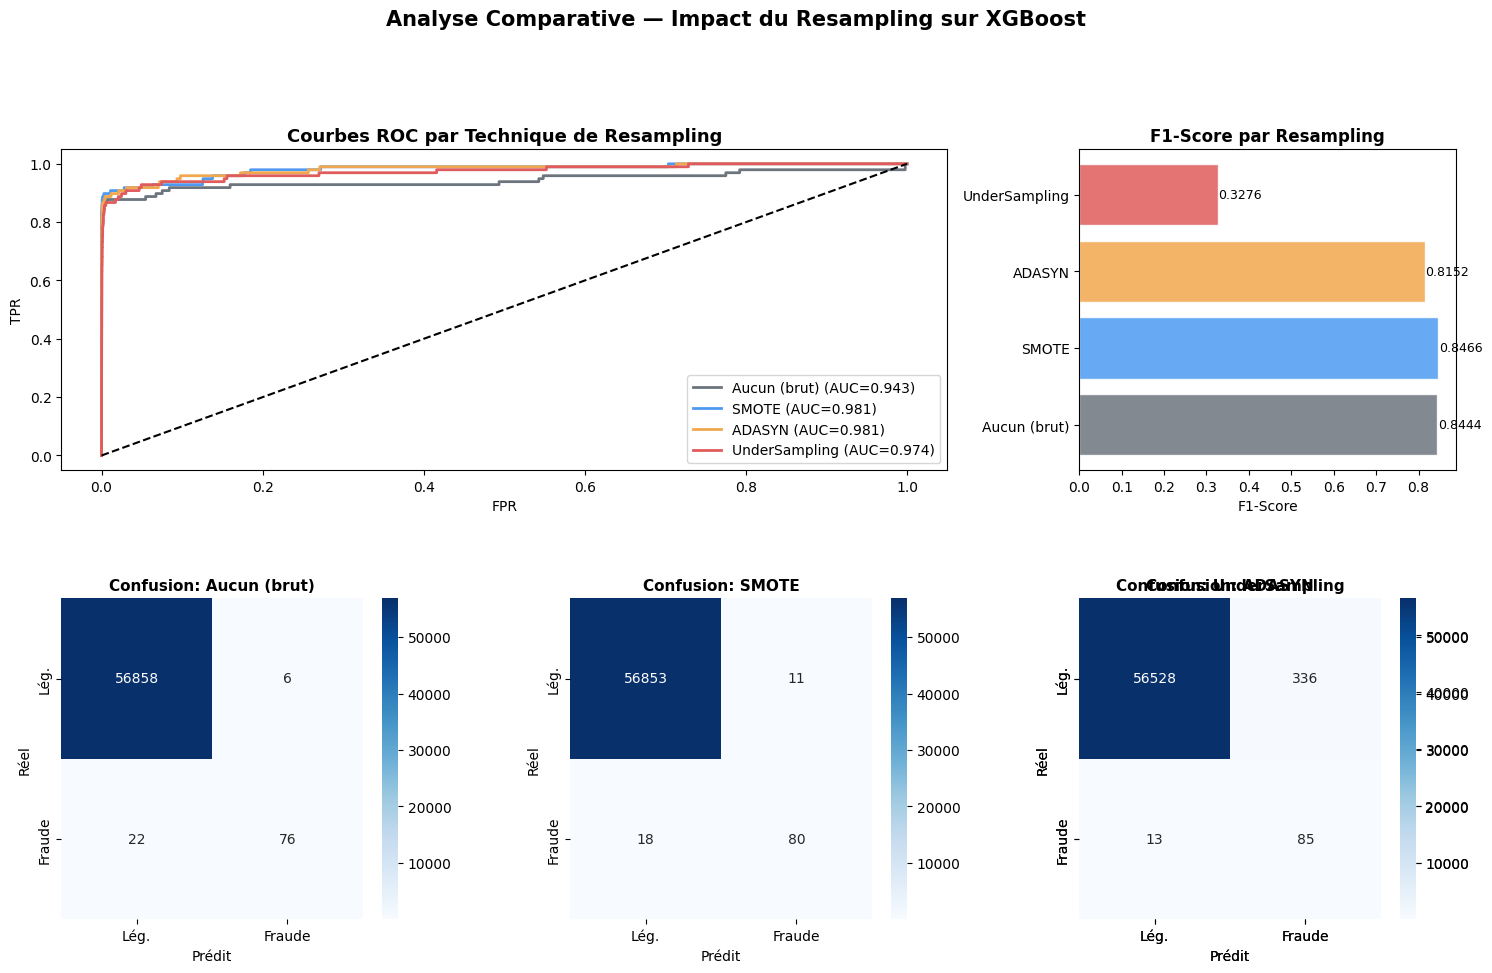

In [7]:
if results_imb:
    df_imb = pd.DataFrame(results_imb).set_index('Resampling')

    print("\n📊 IMPACT DES TECHNIQUES DE RESAMPLING — XGBoost (Paramètres Fixes)")
    print("=" * 70)
    display(df_imb.style
            .highlight_max(subset=['F1','AUC','Rappel','Précision'], color='#c8e6c9')
            .highlight_min(subset=['F1','AUC'],                      color='#ffcdd2')
            .format({c: '{:.4f}' for c in ['Précision','Rappel','F1','AUC','AUPRC']}))

    # ── Visualisations ───────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

    # ROC Curves
    ax0 = fig.add_subplot(gs[0, :2])
    colors = ['#6c757d', '#4e9af1', '#f1a74e', '#e05c5c']
    for (name, (y_true, y_prob)), color in zip(roc_data_imb.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax0.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax0.plot([0,1],[0,1],'k--')
    ax0.set_xlabel("FPR"); ax0.set_ylabel("TPR")
    ax0.set_title("Courbes ROC par Technique de Resampling", fontsize=13, fontweight='bold')
    ax0.legend(fontsize=10)

    # Bar chart F1
    ax1 = fig.add_subplot(gs[0, 2])
    names = df_imb.index.tolist()
    f1_vals = df_imb['F1'].tolist()
    bar_colors = ['#6c757d', '#4e9af1', '#f1a74e', '#e05c5c'][:len(names)]
    ax1.barh(names, f1_vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax1.set_xlabel("F1-Score")
    ax1.set_title("F1-Score par Resampling", fontsize=12, fontweight='bold')
    for i, (n, v) in enumerate(zip(names, f1_vals)):
        ax1.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

    # Matrices de confusion
    for idx, (name, (y_true, y_pred)) in enumerate(cms.items()):
        ax = fig.add_subplot(gs[1, idx if idx < 3 else 2])
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=["Lég.","Fraude"], yticklabels=["Lég.","Fraude"])
        ax.set_title(f"Confusion: {name}", fontsize=11, fontweight='bold')
        ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")

    plt.suptitle("Analyse Comparative — Impact du Resampling sur XGBoost",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.show()


## ✅ Analyse et Conclusions — Section 4.3

**Résultats attendus :**
- **Sans resampling** : Précision élevée, Rappel très faible → inutile pour la fraude
- **SMOTE** : Bon équilibre Précision/Rappel
- **ADASYN** : Souvent meilleur que SMOTE sur les zones difficiles à classifier
- **Undersampling** : Rapide mais perd beaucoup d'information → performances souvent inférieures

**Conclusion :** SMOTE et ADASYN sont les meilleures stratégies.
Le choix dépend du compromis Précision/Rappel souhaité par la banque.
